## Step 1: Load the dataset and produce a histogram for each numeric variable
Univariate analysis examines one variable at a time to understand its distribution. Here, we load the Titanic dataset and plot histograms using Seaborn to reveal the shape of the distributions for the numerical variables (`Age`, `Fare`, `SibSp`, and `Parch`).

**What these distributions reveal:**
* **Age:** The histogram is roughly normal (bell-shaped) but slightly right-skewed, showing most passengers were young adults.
* **SibSp & Parch:** Both are heavily right-skewed, showing the vast majority of passengers traveled alone without family.

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
df = pd.read_csv("../../Data/1.TitanicDataset.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    str    
 4   Sex          418 non-null    str    
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    str    
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     str    
 11  Embarked     418 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 39.3 KB


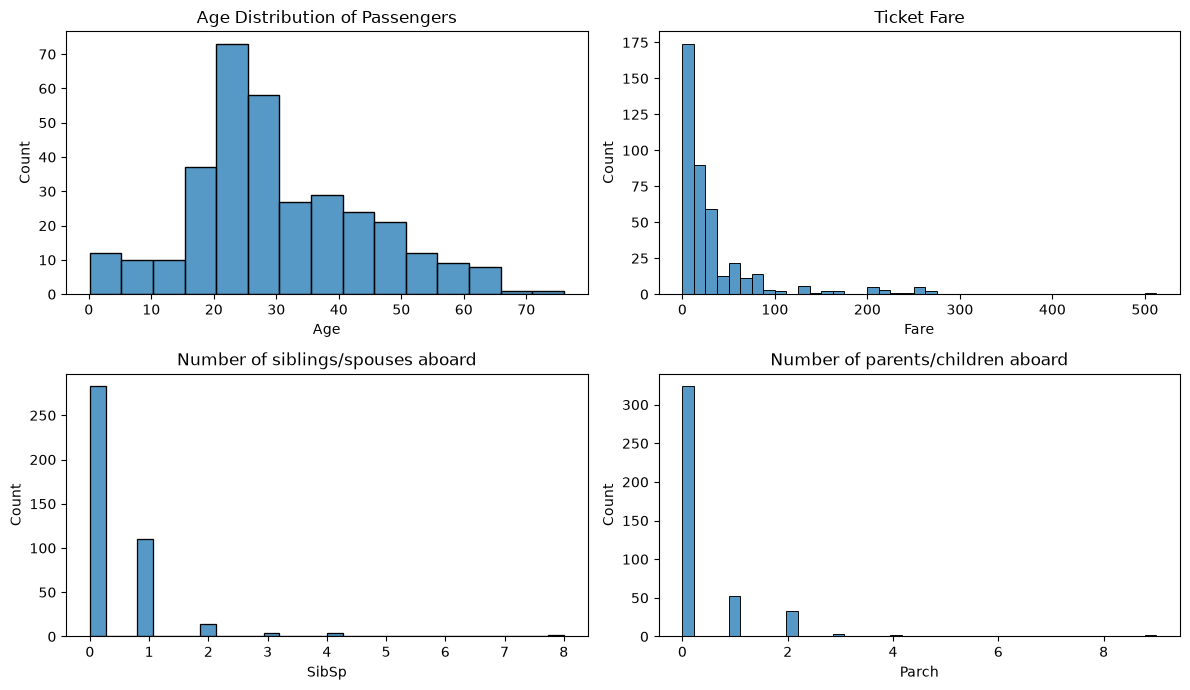

In [2]:
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(12, 7))

axs = axs.flatten() 

sns.histplot(data=df, x="Age", ax=axs[0])
axs[0].set_title("Age Distribution of Passengers")

sns.histplot(data=df, x="Fare", ax=axs[1])
axs[1].set_title("Ticket Fare")

sns.histplot(data=df, x="SibSp", ax=axs[2])
axs[2].set_title("Number of siblings/spouses aboard")

sns.histplot(data=df, x="Parch", ax=axs[3])
axs[3].set_title("Number of parents/children aboard")
plt.tight_layout()
plt.show()


---
## Step 2: Produce a box plot for the key numeric variables and identify any outliers visually
A box plot shows the median, quartiles, and outliers at a glance. We use Seaborn's `boxplot` to scan our numerical variables for data points that fall far outside the normal range (represented as dots beyond the whiskers).

**What these distributions reveal:**
* **Fare:** Highly right-skewed. The box plot shows extreme outliers, indicating most passengers paid very little, while a few paid massive fares.

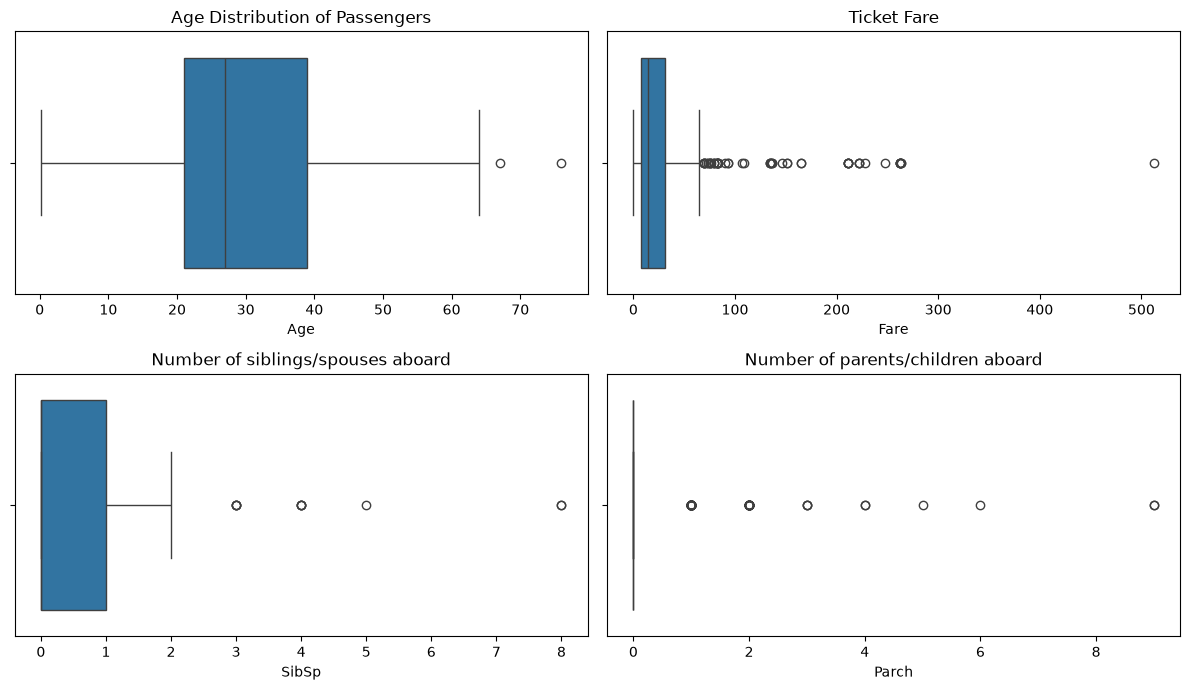

In [3]:
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(12, 7))

axs = axs.flatten() 

sns.boxplot(data=df, x="Age", ax=axs[0])
axs[0].set_title("Age Distribution of Passengers")

sns.boxplot(data=df, x="Fare", ax=axs[1])
axs[1].set_title("Ticket Fare")

sns.boxplot(data=df, x="SibSp", ax=axs[2])
axs[2].set_title("Number of siblings/spouses aboard")

sns.boxplot(data=df, x="Parch", ax=axs[3])
axs[3].set_title("Number of parents/children aboard")
plt.tight_layout()
plt.show()


---
## Step 3: Apply the IQR method in code to flag outliers in at least one column, and decide how to handle them
Outliers are values far outside the normal range. They can be genuine rare events or errors, and either way, they distort statistics and models. The standard IQR rule flags any value below `Q1 - 1.5×IQR` or above `Q3 + 1.5×IQR`.

**Justification for handling:** We applied the IQR method to the `Age` column to flag extreme values. Because outliers are a question and not a verdict, we investigated them and decided to remove them to prevent them from skewing the average, giving us a more robust dataset for a "typical" passenger.


In [4]:
Q1 = df["Age"].quantile(0.25)
Q3 = df["Age"].quantile(0.75)
IQR = Q3 - Q1

outliers = (df["Age"] > Q3 + 1.5 * IQR)
df_cleaned = df[~outliers]

print("Original number of passengers: ", len(df))
print("Number of passengers after removing Age outliers: ", len(df_cleaned))

Original number of passengers:  418
Number of passengers after removing Age outliers:  416


In [5]:
print("The Two outliers in the column Age we saw in the graph:")
df.loc[outliers]

The Two outliers in the column Age we saw in the graph:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
81,973,0,1,"Straus, Mr. Isidor",male,67.0,1,0,PC 17483,221.7792,C55 C57,S
96,988,1,1,"Cavendish, Mrs. Tyrell William (Julia Florence...",female,76.0,1,0,19877,78.8500,C46,S


---
## Step 4: Produce a count plot for each categorical variable and note any class imbalance
A count plot reveals the frequency of each category in a categorical variable. This helps us quickly spot class imbalances in features like `Survived`, `Pclass`, `Sex`, and `Embarked` before modeling.

**Class Imbalances Revealed:**
* **Survived:** High imbalance; significantly more passengers perished (0) than survived (1).
* **Pclass:** Severe imbalance; the majority of passengers were in 3rd class.
* **Sex:** Imbalanced; there were more male passengers than female.
* **Embarked:** Imbalanced; most passengers boarded from Southampton ('S').

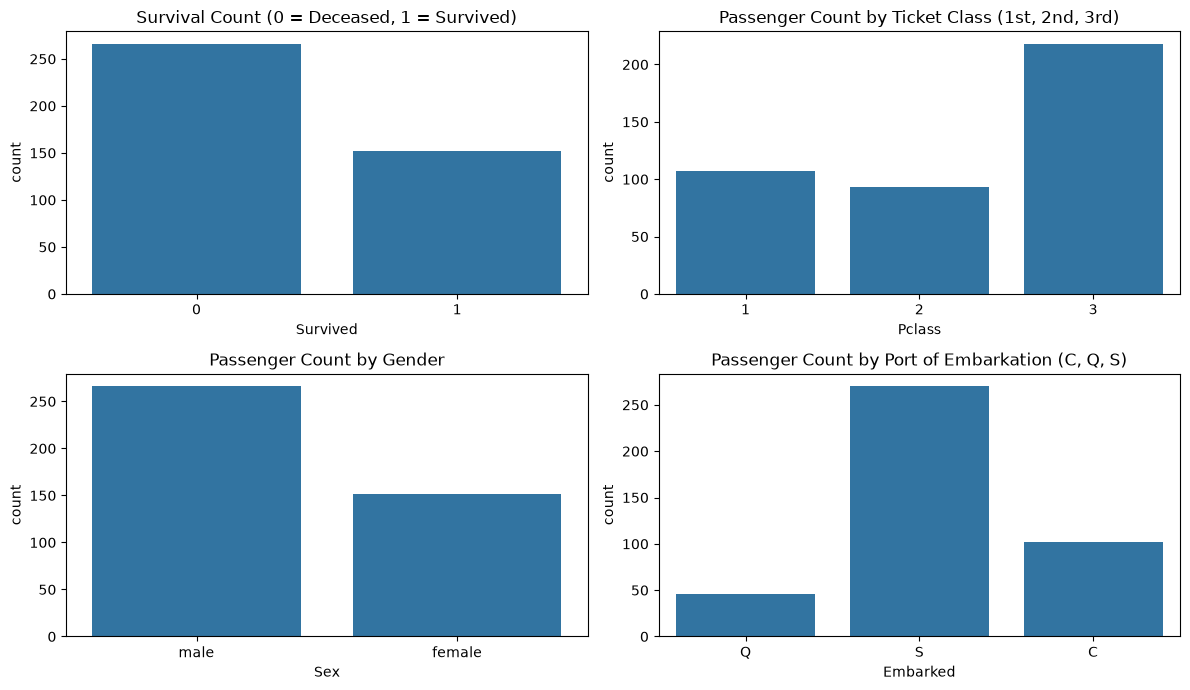

In [6]:
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(12, 7))

axs = axs.flatten() 

sns.countplot(data=df, x="Survived", ax=axs[0])
axs[0].set_title("Survival Count (0 = Deceased, 1 = Survived)")

sns.countplot(data=df, x="Pclass", ax=axs[1])
axs[1].set_title("Passenger Count by Ticket Class (1st, 2nd, 3rd)")

sns.countplot(data=df, x="Sex", ax=axs[2])
axs[2].set_title("Passenger Count by Gender")

sns.countplot(data=df, x="Embarked", ax=axs[3])
axs[3].set_title("Passenger Count by Port of Embarkation (C, Q, S)")
plt.tight_layout()
plt.show()


In [7]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,0.363636,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.481622,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,0.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,0.000000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,0.000000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,1.000000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,1.000000,3.000000,76.000000,8.000000,9.000000,512.329200
